In [115]:
include("PermBasis.jl")
using Printf
include("PlotSetup.jl")

@R_str (macro with 1 method)

In [2]:
function meanfield_dephasing_decay(u, p, t)
    v, w = u
    Γ, ξ, N, γ = p

    C = v^2 - w^2

    dv = -ξ / 2 * C / v - γ / (2v) * (v^2 + w^2 + w)
    dw = -N * Γ * C - γ * (w + 1/2)

    return [dv, dw]
end

function der2(A, dx)ß
    return (A[3:end] .- 2 .* A[2:end-1] .+ A[1:end-2]) ./ dx^2
end

function der(A, dx)
    return (A[3:end] .- A[1:end-2]) ./ (2dx)
end

function der3(A, dx)
    return (A[5:end] .- 2 .* A[4:end-1] .+ 2 .* A[2:end-3] .- A[1:end-4]) ./ (2dx^3)
end

function moving_average(A, n)
    N = length(A)
    B = similar(A, Float64)
    m = div(n, 2)

    for i in 1:N
        lo = max(1, i - m)
        hi = min(N, i + m)
        B[i] = sum(@view A[lo:hi]) / (hi - lo + 1)
    end

    return B
end

moving_average (generic function with 1 method)

┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/G4Ay1/src/integrator_interface.jl:633
┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/G4Ay1/src/integrator_interface.jl:633
┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consid

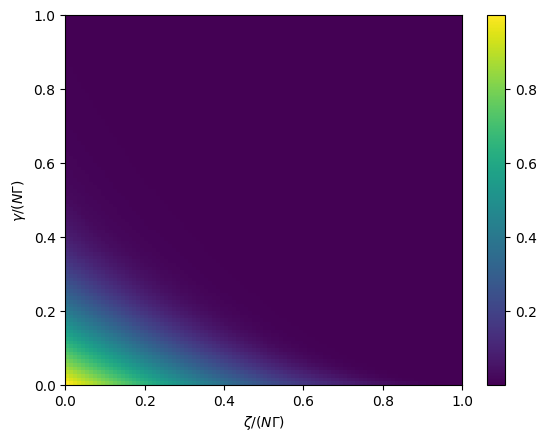

PyObject <matplotlib.colorbar.Colorbar object at 0x1630cc2f0>

In [ ]:
#latex_plot_setup(scale = 2)



res = nothing
N = 1e4
gs = range(0.0, 1.0, 100)
rs = range(0.0, 1.0, 100)
data = zeros(length(gs), length(rs))

j=1
r = 0.0
for (i,g) in enumerate(gs)
    for (j,r) in enumerate(rs)
        #println((i,j))
        Γ = 1.0
        ξ = N * r
        γ = N * g / log(N)
        p = [Γ, ξ, N, γ]

        u0 = [1/2 + 1/N, 1/2]
        tmax = 1.0 / sqrt(N)

        prob = ODEProblem( meanfield_dephasing_decay, u0, (0.0, tmax), p; saveat = range(0.0, tmax, 1000))

        mfsol = solve(prob, RK4())
        intens = map(x -> 4 * (x[1]^2 - x[2]^2), mfsol.u)
        data[i,j] = maximum(intens)
    end
end


imshow(data; extent = (first(rs), last(rs), first(gs), last(gs)), origin = "lower", aspect = "auto")

xlabel(L"\zeta/(N\Gamma)")
ylabel(L"\gamma/(N\Gamma)")
colorbar()

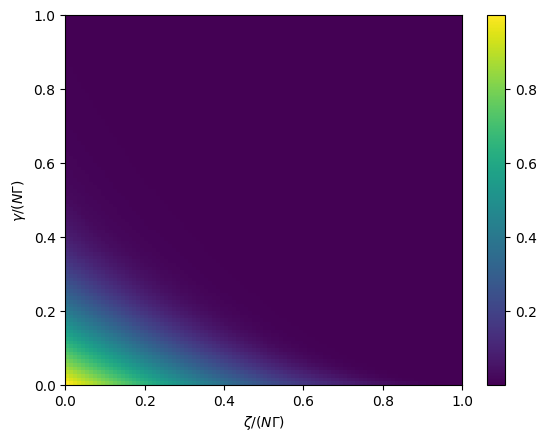

PyObject <matplotlib.colorbar.Colorbar object at 0x170b35400>

In [21]:
imshow(data; extent = (first(rs), last(rs), first(gs), last(gs)), origin = "lower", aspect = "auto")

xlabel(L"\zeta/(N\Gamma)")
ylabel(L"\gamma/(N\Gamma)")
colorbar()

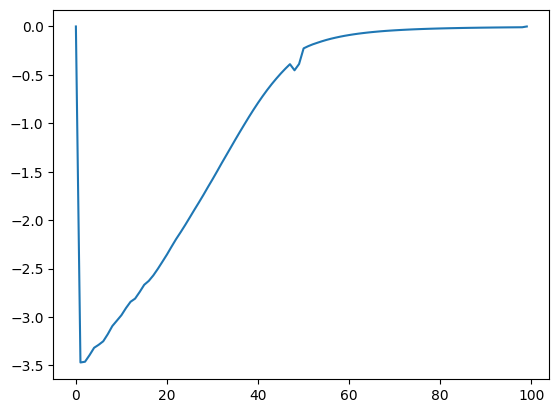

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x1727234d0>

In [55]:
plot(dx(data[:,1], gs[2]-gs[1]))

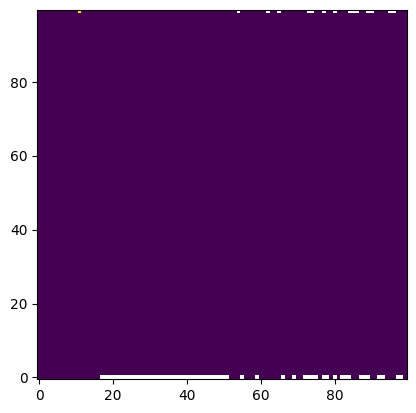

PyObject <matplotlib.image.AxesImage object at 0x1726f20d0>

In [54]:
function d2x(A, dx)
    B = similar(A)
    B[2:end-1, :] .= (A[3:end, :] .- 2 .* A[2:end-1, :] .+ A[1:end-2, :]) ./ dx^2
    return B
end

function d2y(A, dy)
    B = similar(A)
    B[:, 2:end-1] .= (A[:, 3:end] .- 2 .* A[:, 2:end-1] .+ A[:, 1:end-2]) ./ dy^2
    return B
end

function dx(A, dx)
    B = similar(A)
    B[2:end-1, :] .= (A[3:end, :] .- A[1:end-2, :]) ./ (2dx)
    return B
end

function dy(A, dy)
    B = similar(A)
    B[:, 2:end-1] .= (A[:, 3:end] .- A[:, 1:end-2]) ./ (2dy)
    return B
end

imshow(d2x(data, gs[2]-gs[1]), origin = "lower")

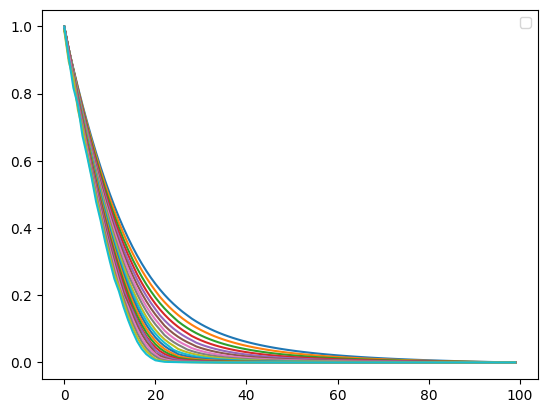

PyObject <matplotlib.legend.Legend object at 0x15d110c20>

In [61]:
function meanfield_dephasing_decay(u, p, t)
    v, w = u
    Γ, ξ, N, γ = p

    C = v^2 - w^2

    dv = -ξ / 2 * C / v - γ / (2v) * (v^2 + w^2 + w)
    dw = -N * Γ * C - γ * (w + 1/2)

    return [dv, dw]
end

res = nothing
N = 1e4
gs = range(0.0, 2.0, 100)
rs = range(0.0, 2.0, 100)
data = zeros(length(gs), length(rs))

j=1
r = 0.0
totres = []
for N in 10 .^ range(2,6, 20)
    res = []
    for (i,g) in enumerate(range(0.0, 2.0, 100))
        Γ = 1.0
        ξ = N * r * 0.0
        γ = N * g / log(N)
        p = [Γ, ξ, N, γ]

        u0 = [1/2 + 1/N, 1/2]
        tmax = 1.0 / sqrt(N)

        prob = ODEProblem( meanfield_dephasing_decay, u0, (0.0, tmax), p; saveat = range(0.0, tmax, 1000))

        mfsol = solve(prob, RK4())
        intens = map(x -> 4 * (x[1]^2 - x[2]^2), mfsol.u)
        push!(res, maximum(intens))
    end
    res = res .- minimum(res)
    plot(res)
    push!(totres, res)
end

legend()


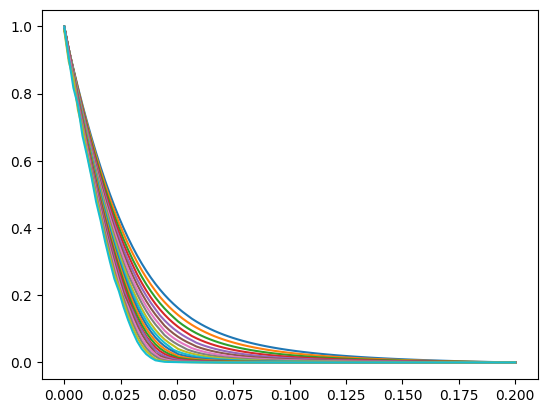

In [64]:
Ns = 10 .^ range(2,6, 20)
for (i,N) in enumerate(Ns)
    γs = range(0.0, 0.2, 100)
    plot(γs, totres[i])
end

Computing N = 1000.0
Computing N = 1097.4987654930555
Computing N = 1204.5035402587823
Computing N = 1321.9411484660286
Computing N = 1450.8287784959402
Computing N = 1592.2827933410922
Computing N = 1747.5284000076829
Computing N = 1917.9102616724888
Computing N = 2104.9041445120197
Computing N = 2310.1297000831605
Computing N = 2535.3644939701117
Computing N = 2782.559402207126
Computing N = 3053.8555088334156
Computing N = 3351.6026509388407
Computing N = 3678.379771828634
Computing N = 4037.017258596554
Computing N = 4430.621457583882
Computing N = 4862.601580065353
Computing N = 5336.699231206308
Computing N = 5857.020818056667
Computing N = 6428.073117284319
Computing N = 7054.8023107186455
Computing N = 7742.63682681127
Computing N = 8497.534359086447
Computing N = 9326.0334688322
Computing N = 10235.31021899027
Computing N = 11233.240329780265
Computing N = 12328.467394420659
Computing N = 13530.477745798076
Computing N = 14849.682622544666
Computing N = 16297.508346206434
Comp

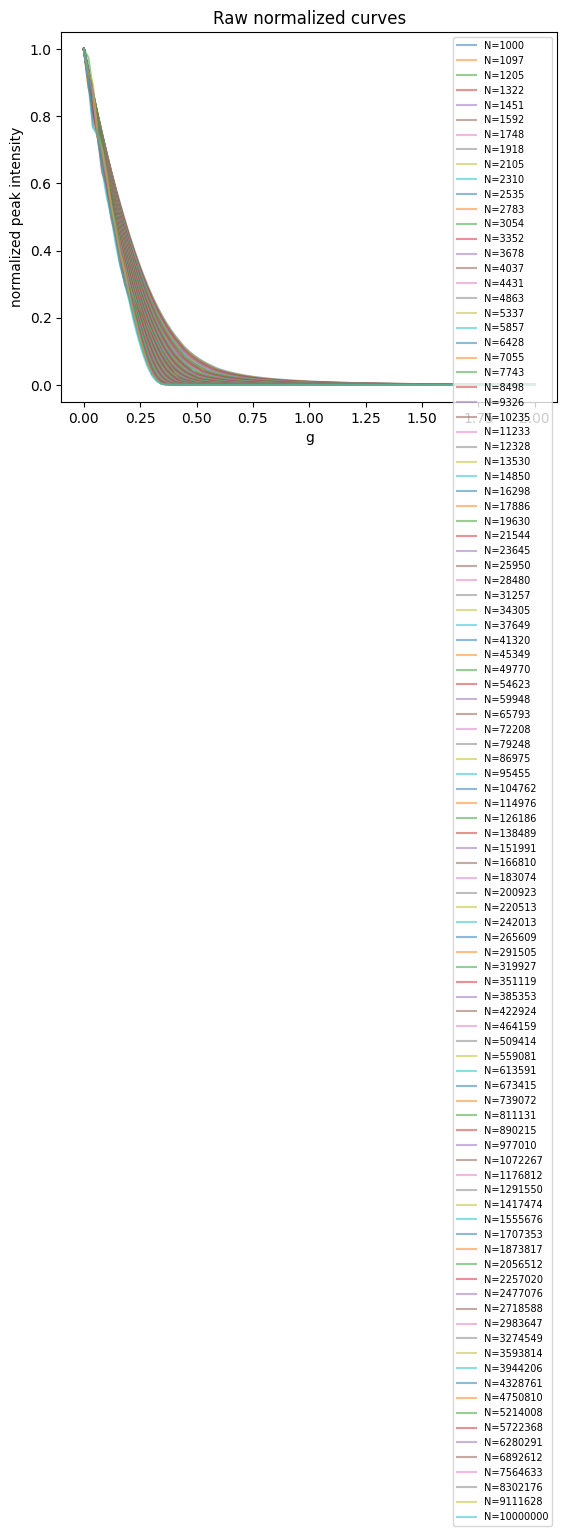

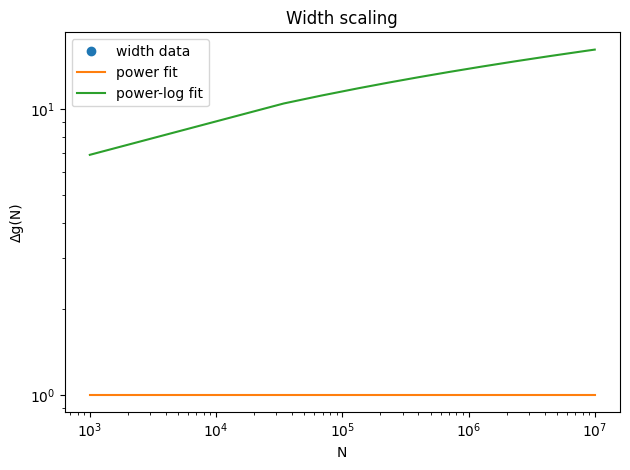

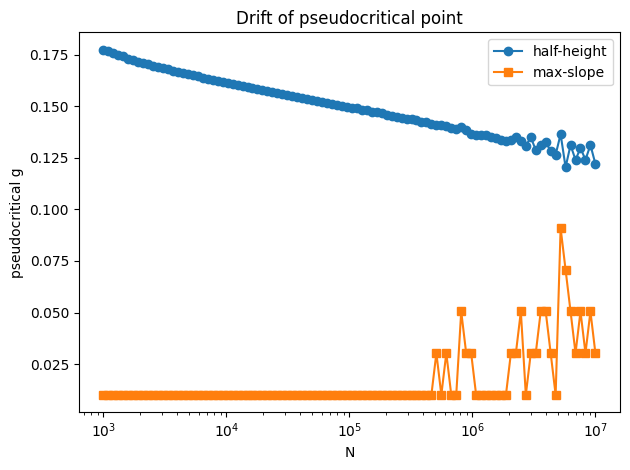

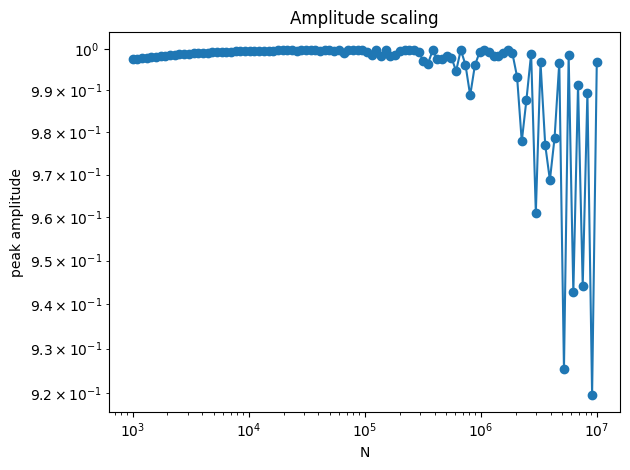

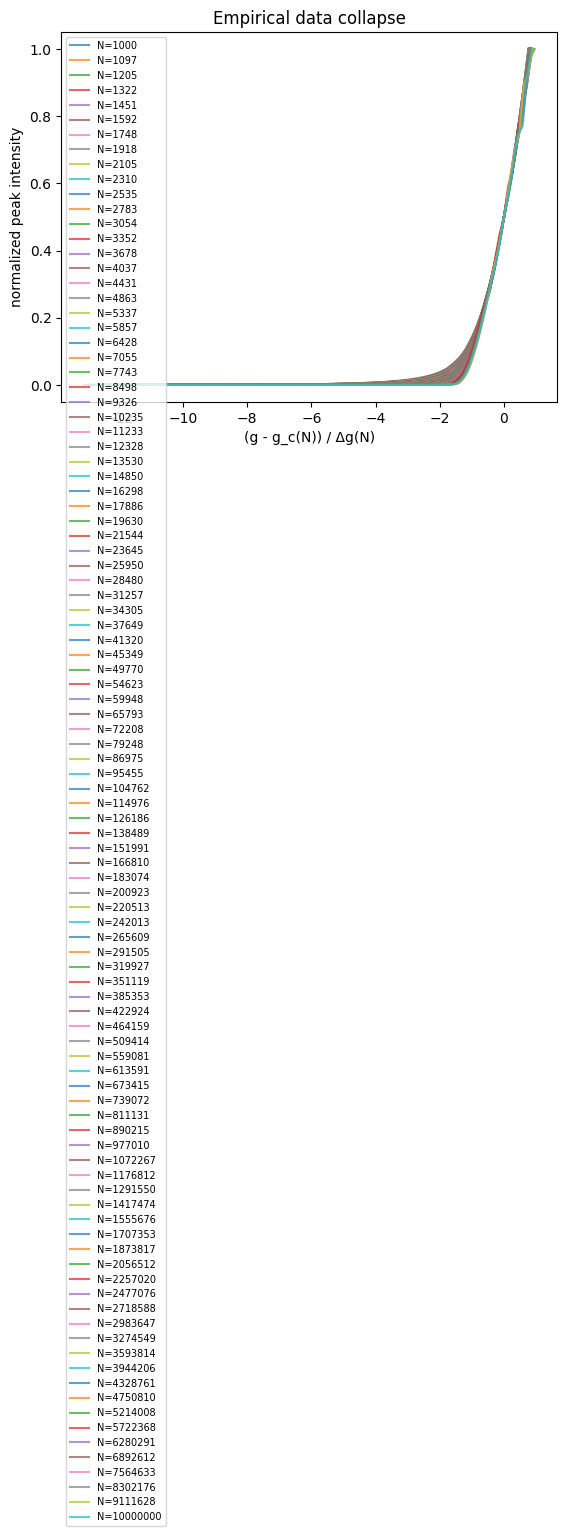

: 

In [ ]:
using DifferentialEquations
using PyPlot
using Statistics
using LsqFit

# ------------------------------------------------------------
# Mean-field equations
# ------------------------------------------------------------
function meanfield_dephasing_decay(u, p, t)
    v, w = u
    Γ, ξ, N, γ = p

    C = v^2 - w^2

    dv = -ξ / 2 * C / v - γ / (2v) * (v^2 + w^2 + w)
    dw = -N * Γ * C - γ * (w + 1/2)

    return [dv, dw]
end

# ------------------------------------------------------------
# Compute one curve R_N(g), where γ = N g / log(N)
# ------------------------------------------------------------
function compute_curve(N; r=0.0, gs=collect(range(0.0, 2.0, length=100)))
    res = Float64[]
    for g in gs
        Γ = 1.0
        ξ = N * r * 0.0
        γ = N * g / log(N)
        p = [Γ, ξ, N, γ]

        u0 = [1/2 + 1/N, 1/2]
        tmax = 0.5 / sqrt(N)

        prob = ODEProblem(
            meanfield_dephasing_decay,
            u0,
            (0.0, tmax),
            p;
            saveat=range(0.0, tmax, length=1000)
        )

        sol = solve(prob, RK4())
        intens = map(x -> 4 * (x[1]^2 - x[2]^2), sol.u)
        push!(res, maximum(intens))
    end
    return res
end

# ------------------------------------------------------------
# Simple inverse interpolation: find x where y crosses y0
# ------------------------------------------------------------
function crossing_x(xs, ys, y0)
    for i in 1:length(xs)-1
        y1, y2 = ys[i], ys[i+1]
        if (y1 - y0) * (y2 - y0) <= 0
            x1, x2 = xs[i], xs[i+1]
            if y2 == y1
                return (x1 + x2) / 2
            end
            return x1 + (y0 - y1) * (x2 - x1) / (y2 - y1)
        end
    end
    return NaN
end

# ------------------------------------------------------------
# Extract pseudocritical point and width from one curve
# ------------------------------------------------------------
function extract_scaling_from_curve(gs, res; subtract_min=true)
    y = copy(res)

    if subtract_min
        y .-= minimum(y)
    end

    ymax = maximum(y)
    if ymax <= 1e-14
        return nothing
    end

    yn = y ./ ymax

    # orient curve so it decreases left -> right
    x = copy(gs)
    z = copy(yn)
    if z[end] > z[1]
        x = reverse(x)
        z = reverse(z)
    end

    g25 = crossing_x(x, z, 0.25)
    g50 = crossing_x(x, z, 0.50)
    g75 = crossing_x(x, z, 0.75)

    d = diff(z) ./ diff(x)
    j = argmin(d)
    gslope = (x[j] + x[j+1]) / 2

    return (
        y = y,
        yn = yn,
        ymax = ymax,
        g25 = g25,
        g50 = g50,
        g75 = g75,
        width = g75 - g25,
        gslope = gslope,
        slope = d[j]
    )
end

# ------------------------------------------------------------
# Fit helpers
# ------------------------------------------------------------
pow_model(x, p) = p[1] .* x .^ p[2]
powlog_model(x, p) = p[1] .* x .^ p[2] .* log.(x) .^ p[3]

function fit_power(xs, ys; p0=[1.0, 0.5])
    mask = .!(isnan.(ys)) .& .!isinf.(ys) .& (ys .> 0)
    return curve_fit(pow_model, xs[mask], ys[mask], p0)
end

function fit_powerlog(xs, ys; p0=[1.0, 0.5, 1.0])
    mask = .!(isnan.(ys)) .& .!isinf.(ys) .& (ys .> 0)
    return curve_fit(powlog_model, xs[mask], ys[mask], p0)
end

# ------------------------------------------------------------
# Main scan
# ------------------------------------------------------------
gs = collect(range(0.0, 2.0, length=100))
Ns = 10.0 .^ range(3, 7, length=100)

totres = Vector{Vector{Float64}}()
stats = NamedTuple[]

figure()
for N in Ns
    println("Computing N = $N")
    res = compute_curve(N; gs=gs)

    info = extract_scaling_from_curve(gs, res)
    if info === nothing
        println("flat curve at N = $N")
        continue
    end

    push!(totres, info.yn)
    push!(stats, (
        N = N,
        g25 = info.g25,
        g50 = info.g50,
        g75 = info.g75,
        width = info.width,
        gslope = info.gslope,
        ymax = info.ymax
    ))

    plot(gs, info.yn, alpha=0.5, label="N=$(round(Int, N))")
end
xlabel("g")
ylabel("normalized peak intensity")
title("Raw normalized curves")
legend(fontsize=7)
tight_layout()

# ------------------------------------------------------------
# Extract arrays
# ------------------------------------------------------------
Ns_fit = [s.N for s in stats]
g25s = [s.g25 for s in stats]
g50s = [s.g50 for s in stats]
g75s = [s.g75 for s in stats]
widths = [s.width for s in stats]
gslopes = [s.gslope for s in stats]
amps = [s.ymax for s in stats]

# ------------------------------------------------------------
# Fits
# ------------------------------------------------------------
fit_width_pow = fit_power(Ns_fit, widths; p0=[1.0, 0.0])
fit_width_powlog = fit_powerlog(Ns_fit, widths; p0=[1.0, 0.0, 1.0])

println("width fit power [a, β] = ", coef(fit_width_pow))
println("width fit powerlog [a, β, λ] = ", coef(fit_width_powlog))

# optional: fit drift of pseudocritical point
valid_g50 = .!(isnan.(g50s))
if any(valid_g50)
    fit_g50_pow = fit_power(Ns_fit[valid_g50], abs.(g50s[valid_g50]); p0=[1.0, 0.0])
    println("g50 fit power [a, β] = ", coef(fit_g50_pow))
end

# ------------------------------------------------------------
# Plot extracted scaling data
# ------------------------------------------------------------
Ns_plot = collect(range(minimum(Ns_fit), maximum(Ns_fit), length=300))

figure()
loglog(Ns_fit, widths, "o", label="width data")
loglog(Ns_plot, pow_model(Ns_plot, coef(fit_width_pow)), label="power fit")
loglog(Ns_plot, powlog_model(Ns_plot, coef(fit_width_powlog)), label="power-log fit")
xlabel("N")
ylabel("Δg(N)")
title("Width scaling")
legend()
tight_layout()

figure()
semilogx(Ns_fit, g50s, "o-", label="half-height")
semilogx(Ns_fit, gslopes, "s-", label="max-slope")
xlabel("N")
ylabel("pseudocritical g")
title("Drift of pseudocritical point")
legend()
tight_layout()

figure()
loglog(Ns_fit, amps, "o-")
xlabel("N")
ylabel("peak amplitude")
title("Amplitude scaling")
tight_layout()

# ------------------------------------------------------------
# Empirical data collapse
# ------------------------------------------------------------
figure()
for (i, s) in enumerate(stats)
    if isnan(s.g50) || isnan(s.width) || s.width == 0
        continue
    end
    x = (gs .- s.g50) ./ s.width
    y = totres[i]
    plot(x, y, alpha=0.7, label="N=$(round(Int, s.N))")
end
xlabel("(g - g_c(N)) / Δg(N)")
ylabel("normalized peak intensity")
title("Empirical data collapse")
legend(fontsize=7)
tight_layout()


In [169]:
gs = range(0.0, 1.2, 4000)
rs = range(0.0, 1.2, 4000)
g = 0.0
resr = []
for (j,r) in enumerate(rs)
    Γ = 1.0
    ξ = N * r
    γ = N * g / log(N)
    p = [Γ, ξ, N, γ]

    u0 = [1/2 + 1/N, 1/2]
    tmax = 1.5 / sqrt(N)

    prob = ODEProblem( meanfield_dephasing_decay, u0, (0.0, tmax), p; saveat = range(0.0, tmax, 1000), abstol = 1e-8, reltol = 1e-8)

    mfsol = solve(prob, RK4())
    intens = map(x -> 4 * (x[1]^2 - x[2]^2), mfsol.u)
    push!(resr, maximum(intens))
end


In [170]:
r = 0.05
resg = []

for (i,g) in enumerate(gs)
    Γ = 1.0
    ξ = N * r
    γ = N * g / log(N)
    p = [Γ, ξ, N, γ]

    u0 = [1/2 + 1/N, 1/2]
    tmax = 2.0 / sqrt(N)

    prob = ODEProblem( meanfield_dephasing_decay, u0, (0.0, tmax), p; saveat = range(0.0, tmax, 1000), abstol = 1e-8, reltol = 1e-8)

    mfsol = solve(prob, RK4())
    intens = map(x -> 4 * (x[1]^2 - x[2]^2), mfsol.u)
    push!(resg, maximum(intens))
end

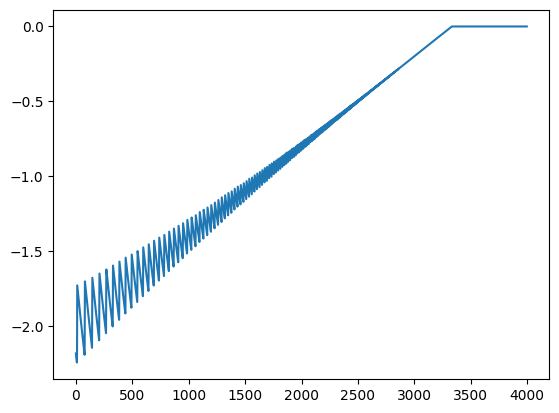

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x174432510>

In [ ]:


plot(der(resr, rs[2] - rs[1]))


In [ ]:
using DiffEqCallbacks

In [27]:
import Pkg; Pkg.add("DiffEqCallbacks")

   Resolving package versions...
    Updating `~/.julia/environments/v1.12/Project.toml`
  [459566f4] + DiffEqCallbacks v4.12.0
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


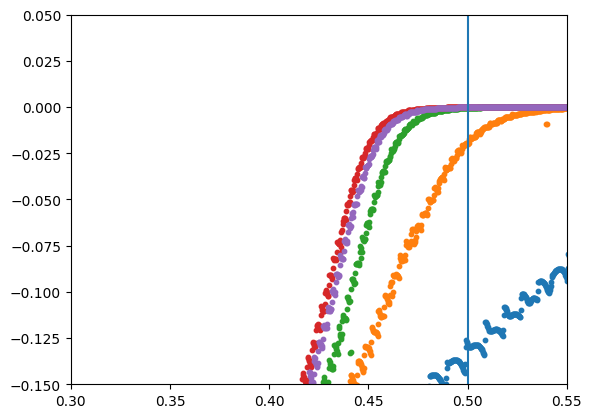

In [104]:
function meanfield_reduced!(du, u, p, t)
    I, m = u
    Γ, ξ, N, γ = p

    # Equations are now linear/quadratic with no denominators
    du[1] = (2 * N * Γ * m - ξ - γ) * I
    du[2] = -N * Γ * I - γ * (m + 0.5)
end

cb = TerminateSteadyState(1e-2, 1e-4)
rs = range(0.2, 1.2, 4000)


for g in [0.1]
    figure()
for pow in [4,10,16,18,23]
    N = 10 ^ pow
        resr = []
        for (i,r) in enumerate(rs)
            Γ = 1.0
            ξ = N * r
            γ = N * g / log(N)
            p = [Γ, ξ, N, γ]

            u0 = [1/N, 1/2]
            tmax = 2.0 * log(N) / N * 1 / abs(1.0 - g - r)

            prob = ODEProblem( meanfield_reduced!, u0, (0.0, 1e10), p)

            mfsol = solve(prob, AutoTsit5(Rosenbrock23()), callback=cb, reltol=1e-8, abstol=1e-10)
            intens = map(x -> x[1], mfsol.u)
            push!(resr, maximum(intens))
        end
        scatter(rs[2:end-1], der(resr, rs[2] - rs[1]), s = 10)
        ylim(bottom = -0.15, top = 0.05)
        xlim(0.3, 0.55)
    end
    axvline(1.0)
    axvline(0.5)
    display(gcf())
end



close("all")


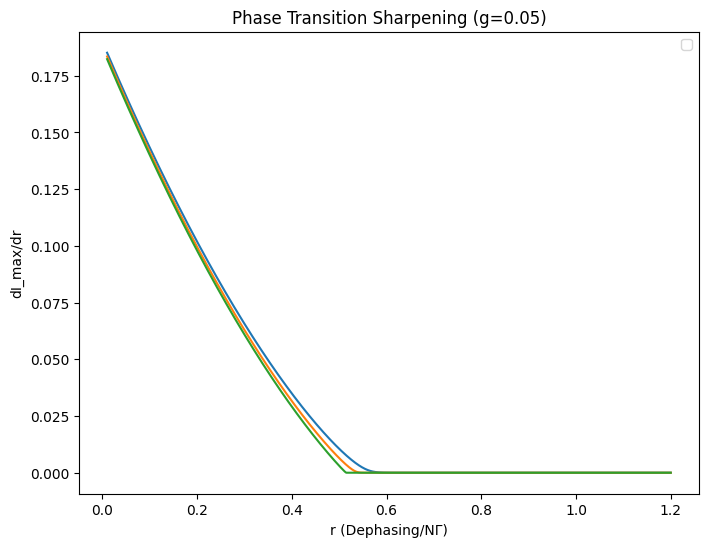

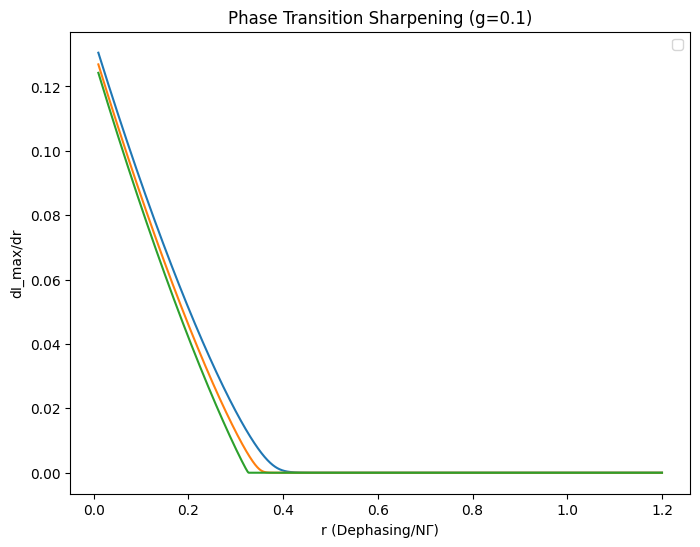

In [ ]:
using DifferentialEquations, DiffEqCallbacks, PyPlot

function meanfield_log_transformed!(du, u, p, t)
    L, m = u  # u[1] is log(I)
    Γ, ξ, N, γ = p

    # d(log I)/dt = (1/I) * dI/dt
    du[1] = (2 * N * Γ * m - ξ - γ)
    
    # dm/dt uses exp(L) to get the current intensity
    # We cap exp(L) at a reasonable max to prevent Inf during transients
    I_current = exp(L)
    du[2] = -N * Γ * I_current - γ * (m + 0.5)
end

# Callback needs to monitor the log-derivative and m-derivative
cb = TerminateSteadyState(1e-1, 1e-1)

rs = range(0.01, 1.2, 200)
gs = [0.05, 0.1]

for g in gs
    figure(figsize=(8,6))
    for pow in [10, 23, 300]
        N = BigInt(10) ^ pow # Use BigInt for parameter calculation if needed
        # Convert to Float64 for the solver
        N_f = Float64(N)
        
        resr = Float64[]
        for r in rs
            Γ = 1.0
            ξ = N_f * r
            γ = N_f * g / log(N_f)
            p = [Γ, ξ, N_f, γ]

            # Initial condition: log(1/N) = -log(N)
            u0 = [-log(N_f), 0.5]

            # We use a stiff-aware solver because N=10^23 is naturally stiff
            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, 1e15), p)
            
            # Using Rodas5P or Rosenbrock23 is safer for these scales
            sol = solve(prob, Rosenbrock23(), callback=cb, reltol=1e-8, abstol=1e-10)
            
            # Recover max intensity: exp(maximum of log-intensity)
            # or just map the first component
            max_log_I = maximum(x -> x[1], sol.u)
            push!(resr, exp(max_log_I))
        end
        
        # Plotting the derivative to see the phase transition sharpening
        plot(rs, resr)
       # dI_dr = (resr[3:end] .- resr[1:end-2]) ./ (rs[3]-rs[1])
        #plot(rs[2:end-1], dI_dr, label="10^$pow")
    end
    
    #ylim(-0.4, 0.1)
    legend()
    xlabel("r (Dephasing/NΓ)")
    ylabel("dI_max/dr")
    title("Phase Transition Sharpening (g=$g)")
    display(gcf())
end

close("all")


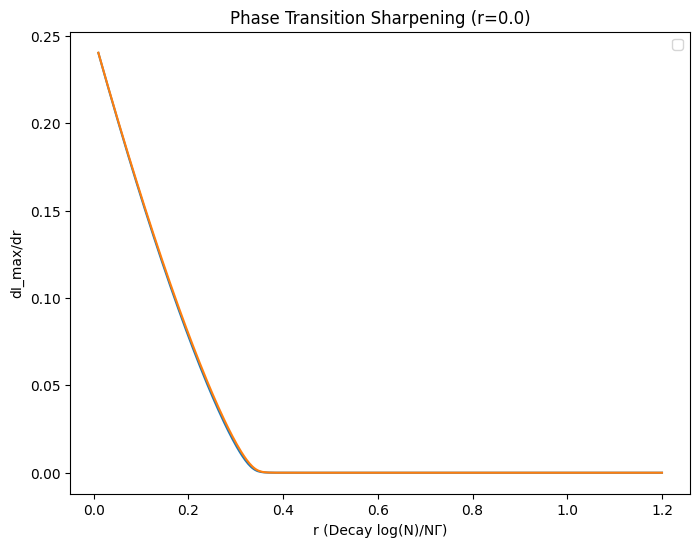

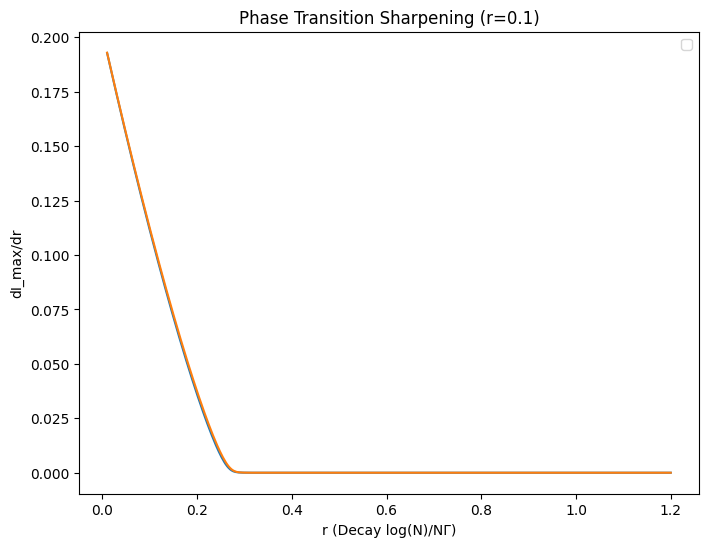

In [26]:
# Callback needs to monitor the log-derivative and m-derivative
cb = TerminateSteadyState(1e-1, 1e-1)

gs = range(0.01, 1.2, 400)
rs = [0.0, 0.1]
pow = 23
for r in rs
    figure(figsize=(8,6))
    for alpha in [0.0, 0.01]
        N = BigInt(10) ^ pow # Use BigInt for parameter calculation if needed
        # Convert to Float64 for the solver
        N_f = Float64(N)
        
        resr = Float64[]
        for g in gs
            Γ = 1.0
            ξ = N_f * r
            γ = N_f * g / log(N_f)
            p = [Γ, ξ, N_f, γ]

            # Initial condition: log(1/N) = -log(N)
            u0 = [(alpha - 1)*log(N_f), 0.5 -  N_f ^ (alpha-1)]

            # We use a stiff-aware solver because N=10^23 is naturally stiff
            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, 1e15), p)
            
            # Using Rodas5P or Rosenbrock23 is safer for these scales
            sol = solve(prob, Rosenbrock23(), callback=cb, reltol=1e-8, abstol=1e-10)
            
            # Recover max intensity: exp(maximum of log-intensity)
            # or just map the first component
            max_log_I = maximum(x -> x[1], sol.u)
            push!(resr, exp(max_log_I))
        end
        
        plot(gs, resr)
    end
    
    #ylim(-0.4, 0.1)
    legend()
    xlabel("r (Decay log(N)/NΓ)")
    ylabel("dI_max/dr")
    title("Phase Transition Sharpening (r=$r)")
    display(gcf())
end

close("all")

# Implement mathcing from linearized moments

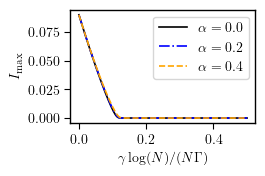

In [ ]:
using DifferentialEquations
using DiffEqCallbacks

# -----------------------------
# Linearized moment equations
# u = [⟨n⟩, ⟨m⟩, ⟨n²⟩, ⟨nm⟩, ⟨m²⟩]
# -----------------------------
function linearized_moments!(du, u, p, t)
    n, m, n2, nm, m2 = u
    Γ, ξ, N, γ = p
    a = N * Γ + γ

    du[1] = a + (a - ξ) * n
    du[2] = -a * (1 + n) - γ * N
    du[3] = a + (3a + ξ) * n + 2 * (a - ξ) * n2
    du[4] = -a - (2a + γ * N) * n + a * m - a * n2 + (a - ξ) * nm
    du[5] = (a + γ * N) + a * n - 2 * (a + γ * N) * m - 2 * a * nm
end

# Exact intensity in (n,m) variables:
# I = (2m+n)(n+1)
linearized_intensity(u) = 2u[4] + 2u[2] + u[3] + u[1]

# -----------------------------
# Bulk mean-field in log-intensity variables
# u = [L, mbar] with L = log(𝓘), 𝓘 = I/N², mbar = m/N
# -----------------------------
function bulk_meanfield_log!(du, u, p, t)
    L, mbar = u
    Γ, ξ, N, γ = p

    du[1] = 2 * N * Γ * mbar - ξ - γ

    Ibar = exp(L)
    du[2] = -N * Γ * Ibar - γ * (mbar + 0.5)
end

# -----------------------------
# Main hybrid solver
# alpha defines matching via ⟨n⟩ = N^alpha
# -----------------------------
function solve_hybrid_matched(Γ, ξ, N, γ;
    alpha = 0.1,
    tmax_linear = 1e15,
    tmax_bulk = 1e15,
    reltol = 1e-9,
    abstol = 1e-12)

    Nf = Float64(N)
    p = (Γ, ξ, Nf, γ)

    # Initial fully excited state:
    # n = s-m = 0, m = N/2
    u0_lin = [0.0, Nf/2, 0.0, 0.0, (Nf/2)^2]

    n_match = Nf^alpha

    # terminate linearized evolution when ⟨n⟩ reaches N^alpha
    condition(u, t, integrator) = u[1] - n_match
    affect!(integrator) = terminate!(integrator)
    cb_match = ContinuousCallback(condition, affect!)

    prob_lin = ODEProblem(linearized_moments!, u0_lin, (0.0, tmax_linear), p)
    sol_lin = solve(prob_lin, Rosenbrock23();
        callback = cb_match,
        reltol = reltol,
        abstol = abstol)

    u_match = sol_lin.u[end]
    t_match = sol_lin.t[end]

    n_match_val  = u_match[1]
    m_match_val  = u_match[2]
    I_match_val  = linearized_intensity(u_match)

    # Safety checks
    if I_match_val <= 0
        error("Matched intensity is non-positive. Matching failed.")
    end

    # Initialize bulk intensive variables
    Ibar_match = I_match_val / Nf^2
    mbar_match = m_match_val / Nf

    if Ibar_match <= 0
        error("Matched intensive intensity is non-positive.")
    end

    u0_bulk = [log(Ibar_match), mbar_match]

    # Stop bulk when close to steady state
    cb_bulk = TerminateSteadyState(1e-10, 1e-10)

    prob_bulk = ODEProblem(bulk_meanfield_log!, u0_bulk, (t_match, tmax_bulk), p)
    sol_bulk = solve(prob_bulk, Rosenbrock23();
        callback = cb_bulk,
        reltol = reltol,
        abstol = abstol)

    return (
        linear = sol_lin,
        bulk = sol_bulk,
        t_match = t_match,
        u_match = u_match,
        n_match = n_match_val,
        m_match = m_match_val,
        I_match = I_match_val,
        Ibar_match = Ibar_match,
        mbar_match = mbar_match
    )
end

Γ = 1.0
N = 1e23
r = 0.4
gs = range(0.0, 0.5, 200)
ξ = N * r

figure(figsize = latex_plot_setup())

for α in [0, 0., 0.4]
    gres = []
    for g in gs
        γ = N * g / log(N)

        res = solve_hybrid_matched(Γ, ξ, N, γ; alpha=α)
        max_log_Ibar = maximum(u -> u[1], res.bulk.u)
        Ibar_max = exp(max_log_Ibar)
        push!(gres, Ibar_max)
    end

    plot(gs, gres, label = "\$\\alpha=$α\$")
end

xlabel(L"\gamma \log(N)/(N\Gamma)")
ylabel(L"I_{\text{max}}")
legend()
savefig("../data/alpha_scaling.pdf", bbox_inches = "tight")
display(gcf())
close("all")


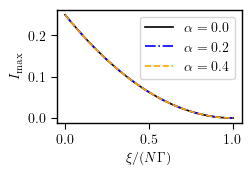

In [125]:
Γ = 1.0
N = 1e23
g = 0.0
r = 0.4
gs = range(0.0, 0.5, 200)
rs = range(0.0, 1.0, 200)
γ = N * g / log(N)

figure(figsize = latex_plot_setup())

for α in [0, 0.2, 0.4]
    rres = []
    for r in rs
        ξ = N * r

        res = solve_hybrid_matched(Γ, ξ, N, γ; alpha=α)
        max_log_Ibar = maximum(u -> u[1], res.bulk.u)
        Ibar_max = exp(max_log_Ibar)
        push!(rres, Ibar_max)
    end

    plot(rs, rres, label = "\$\\alpha=$α\$")
end

xlabel(L"\xi/(N\Gamma)")
ylabel(L"I_{\text{max}}")
legend()
#savefig("../data/alpha_scaling.pdf", bbox_inches = "tight")
display(gcf())
close("all")

In [281]:
# Callback needs to monitor the log-derivative and m-derivative
cb = TerminateSteadyState(1e-1, 1e-1)

gs = range(0.0, 0.38, 200)
rs = range(0.0, 1.2, 200)
data = zeros(length(rs), length(gs))
pow = 200
N = BigInt(10) ^ pow
N_f = Float64(N)

for (i,r) in enumerate(rs)
    for (j,g) in enumerate(gs)
        Γ = 1.0
        ξ = N_f * r
        γ = N_f * g / log(N_f)
        p = [Γ, ξ, N_f, γ]

        # Initial condition: log(1/N) = -log(N)
        u0 = [-log(N_f), 0.5]
        prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, 1e15), p)
        sol = solve(prob, Rosenbrock23(), callback=cb, reltol=1e-8, abstol=1e-10)
        data[i, j] = exp(maximum(x -> x[1], sol.u))
    end        
end


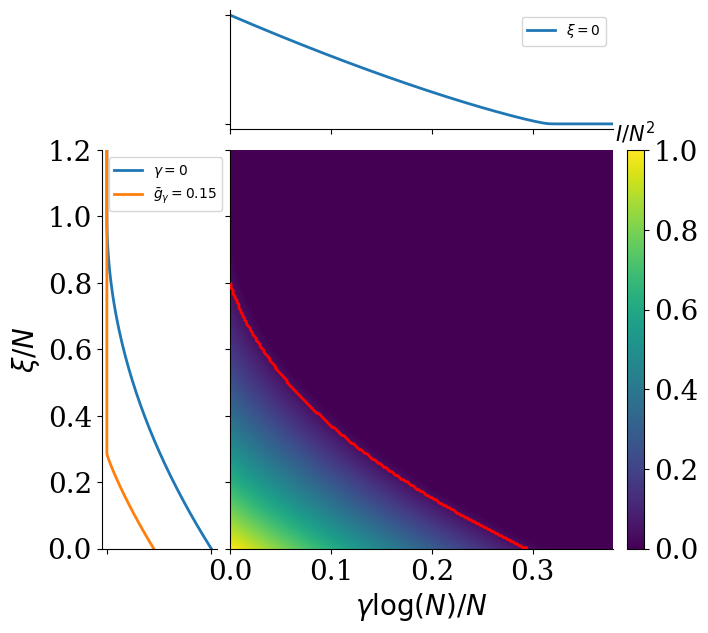

In [275]:
using PyPlot
using PyCall

PyPlot.matplotlib.rc("font", family="serif", size=20)

fig = figure(figsize=(7,7))
gspec = fig.add_gridspec(
    2, 3,
    width_ratios = [1.2, 4.0, 0.18],
    height_ratios = [1.2, 4.0],
    wspace = 0.08,
    hspace = 0.08
)

ax_blank = fig.add_subplot(gspec[1,1])
ax_blank.axis("off")

ax_top  = fig.add_subplot(gspec[1, 2])
ax_left = fig.add_subplot(gspec[2, 1])
ax_main = fig.add_subplot(gspec[2, 2], sharex=ax_top, sharey=ax_left)
ax_cbar = fig.add_subplot(gspec[2, 3])

# Main imshow
im = ax_main.imshow(
    data * 4,
    extent = [first(gs), last(gs), first(rs), last(rs)],
    origin = "lower",
    aspect = "auto"
)

# Only x-label on main
ax_main.set_xlabel(L"\gamma \log(N)/N")
ax_main.set_ylabel("")  # remove from main

# Zero-region boundary
tol = 1e-2
mask = Float64.(data .<= tol)

ax_main.contour(
    collect(gs), collect(rs), mask,
    levels = [0.5],
    colors = "red",
    linewidths = 2,
    zorder = 10
)

# Top plot: r = 0 slice
ax_top.plot(collect(gs), 4 .* data[1, :], lw = 2,label = L"\xi=0")
ax_top.tick_params(axis = "x", labelbottom = false)
ax_top.tick_params(axis = "y", labelleft = false)
ax_top.legend(fontsize = 10)

# Left plot: g = 0 slice
ax_left.plot(4 .* data[:, 1], collect(rs), lw = 2, label = L"\gamma=0")
ax_left.plot(4 .* data[:, 80], collect(rs), lw = 2, label = @sprintf("\$\\bar g_\\gamma=%.2f\$", gs[80]))
ax_left.legend(fontsize = 10)

# Put the y-label HERE
ax_left.set_ylabel(L"\xi/N")

# Keep ticks clean
ax_left.tick_params(axis = "x", labelbottom = false)
ax_main.tick_params(axis = "y", labelleft = false)

# Clean up spines
ax_top.spines["right"].set_visible(false)
ax_top.spines["top"].set_visible(false)

ax_left.spines["right"].set_visible(false)
ax_left.spines["top"].set_visible(false)

ax_main.spines["top"].set_visible(false)
ax_main.spines["right"].set_visible(false)

# Align axes
ax_top.set_xlim(first(gs), last(gs))
ax_left.set_ylim(first(rs), last(rs))

# Colorbar
clb = fig.colorbar(im, cax=ax_cbar)
clb.ax.set_title(L"I/N^2", fontsize = 15)
savefig("../data/mean_field_phase_$pow.pdf", bbox_inches = "tight")

display(gcf())
close("all")

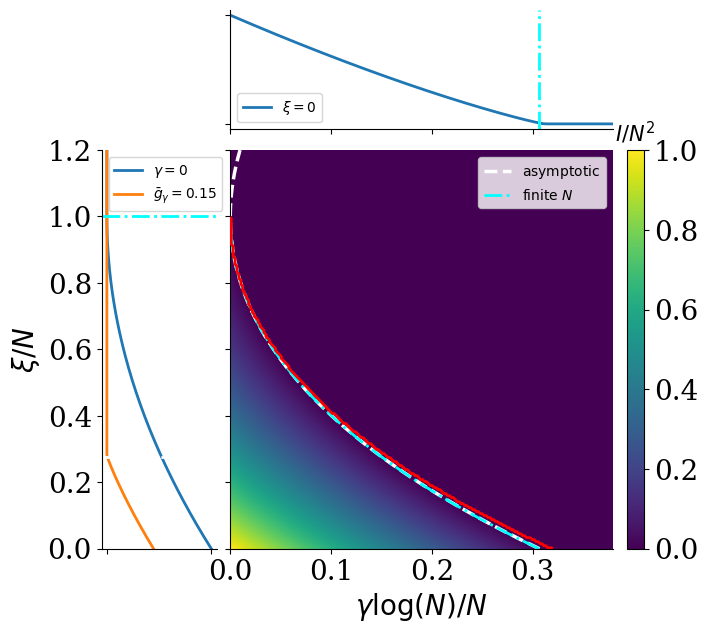

In [ ]:
using PyPlot
using PyCall

PyPlot.matplotlib.rc("font", family="serif", size=20)

# ---------- analytic boundary ----------
# r = g_xi = xi/N
# x = g_gamma * log(N) = gamma log(N)/N

# leading large-N boundary:
boundary_asymptotic(r) = 1 - r - (1 + r) * log(2 / (1 + r))

# finite-N implicit boundary:
# x = 1-r-g-(1+r+g) log(2/(1+r+g)),  with g = x/logN
function boundary_finiteN(r, logN; tol=1e-10, maxiter=200)
    f(x) = x - (
        1 - r - x/logN
        - (1 + r + x/logN) * log(2 / (1 + r + x/logN))
    )

    # boundary only exists for r < 1 in this linear theory
    if r >= 1
        return NaN
    end

    # bracket root on plotted x-range
    a = 0.0
    b = max(1.0, 2first(gs), last(gs))

    fa = f(a)
    fb = f(b)

    # expand bracket if needed
    ntry = 0
    while fa * fb > 0 && ntry < 50
        b *= 1.5
        fb = f(b)
        ntry += 1
    end

    if fa * fb > 0
        return NaN
    end

    # bisection
    for _ in 1:maxiter
        c = 0.5 * (a + b)
        fc = f(c)
        if abs(fc) < tol || abs(b - a) < tol
            return c
        end
        if fa * fc <= 0
            b = c
            fb = fc
        else
            a = c
            fa = fc
        end
    end
    return 0.5 * (a + b)
end

# choose the same r-grid as your image
rgrid = collect(rs)

# infer logN from your filename exponent if that is what `pow` means:
# N = 10^pow  => log(N) = pow * log(10)
logN = pow * log(10)

x_boundary_asym = [boundary_asymptotic(r) for r in rgrid]
x_boundary_finN = [boundary_finiteN(r, logN) for r in rgrid]

# keep only visible / physical points
mask_asym = isfinite.(x_boundary_asym) .& (x_boundary_asym .>= first(gs)) .& (x_boundary_asym .<= last(gs))
mask_finN = isfinite.(x_boundary_finN) .& (x_boundary_finN .>= first(gs)) .& (x_boundary_finN .<= last(gs))

fig = figure(figsize=(7,7))
gspec = fig.add_gridspec(
    2, 3,
    width_ratios = [1.2, 4.0, 0.18],
    height_ratios = [1.2, 4.0],
    wspace = 0.08,
    hspace = 0.08
)

ax_blank = fig.add_subplot(gspec[1,1])
ax_blank.axis("off")

ax_top  = fig.add_subplot(gspec[1, 2])
ax_left = fig.add_subplot(gspec[2, 1])
ax_main = fig.add_subplot(gspec[2, 2], sharex=ax_top, sharey=ax_left)
ax_cbar = fig.add_subplot(gspec[2, 3])

# Main imshow
im = ax_main.imshow(
    data * 4,
    extent = [first(gs), last(gs), first(rs), last(rs)],
    origin = "lower",
    aspect = "auto"
)

# Only x-label on main
ax_main.set_xlabel(L"\gamma \log(N)/N")
ax_main.set_ylabel("")

# numerical zero-region boundary
tol = 1e-8
mask = Float64.(data .<= tol)

ax_main.contour(
    collect(gs), collect(rs), mask,
    levels = [0.5],
    colors = "red",
    linewidths = 2,
    zorder = 10
)

# analytic boundaries
ax_main.plot(
    x_boundary_asym[mask_asym], rgrid[mask_asym],
    color = "white", lw = 2.5, ls = "--",
    label = L"\mathrm{asymptotic}"
)

ax_main.plot(
    x_boundary_finN[mask_finN], rgrid[mask_finN],
    color = "cyan", lw = 2.0, ls = "-.",
    label = L"\mathrm{finite}\ N"
)

ax_main.legend(fontsize = 10, loc = "upper right")

# Top plot: r = 0 slice
ax_top.plot(collect(gs), 4 .* data[1, :], lw = 2, label = L"\xi=0")

# mark analytic intercepts at r=0
x0_asym = boundary_asymptotic(first(rs))
#x0_finN = boundary_finiteN(first(rs), logN)

if isfinite(x0_asym)
    ax_top.axvline(x0_asym, color = "white", lw = 2, ls = "--")
end
#if isfinite(x0_finN)
#    ax_top.axvline(x0_finN, color = "cyan", lw = 2, ls = "-.")
#end

ax_top.tick_params(axis = "x", labelbottom = false)
ax_top.tick_params(axis = "y", labelleft = false)
ax_top.legend(fontsize = 10)

# Left plot: g = 0 slice
ax_left.plot(4 .* data[:, 1], collect(rs), lw = 2, label = L"\gamma=0")
ax_left.plot(4 .* data[:, 80], collect(rs), lw = 2, label = @sprintf("\$\\bar g_\\gamma=%.2f\$", gs[80]))

# mark where chosen vertical slice intersects analytic boundaries
gsel = gs[80]

# find r where boundary(r) = gsel by nearest match
function nearest_intersection(xcurve, rgrid, xval)
    diffs = abs.(xcurve .- xval)
    i = argmin(diffs)
    return rgrid[i]
end

r_int_asym = nearest_intersection(x_boundary_asym, rgrid, gsel)
r_int_finN = nearest_intersection(x_boundary_finN, rgrid, gsel)

ax_left.axhline(r_int_asym, color = "white", lw = 2, ls = "--")
ax_left.axhline(r_int_finN, color = "cyan", lw = 2, ls = "-.")

ax_left.legend(fontsize = 10)

# Put the y-label HERE
ax_left.set_ylabel(L"\xi/N")

# Keep ticks clean
ax_left.tick_params(axis = "x", labelbottom = false)
ax_main.tick_params(axis = "y", labelleft = false)

# Clean up spines
ax_top.spines["right"].set_visible(false)
ax_top.spines["top"].set_visible(false)

ax_left.spines["right"].set_visible(false)
ax_left.spines["top"].set_visible(false)

ax_main.spines["top"].set_visible(false)
ax_main.spines["right"].set_visible(false)

# Align axes
ax_top.set_xlim(first(gs), last(gs))
ax_left.set_ylim(first(rs), last(rs))

# Colorbar
clb = fig.colorbar(im, cax=ax_cbar)
clb.ax.set_title(L"I/N^2", fontsize = 15)

#savefig("../data/mean_field_phase_$pow.pdf", bbox_inches = "tight")
display(gcf())
close("all")